# NOTEBOOK 03: *CLUSTERING*

In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
print("Working with these versions of libraries\n")
print("-"*50)
print(f"pandas  version {pd.__version__}")
print(f"numpy   version {np.__version__}")
print(f"sklearn   version {sklearn.__version__}")
print(f"seaborn version {sns.__version__}")

Working with these versions of libraries

--------------------------------------------------
pandas  version 2.2.3
numpy   version 2.2.2
sklearn   version 1.6.1
seaborn version 0.13.2


# Funciones

In [3]:
def encontrar_codo(wcss):

    x = np.arange(1, len(wcss) + 1)
    y = np.array(wcss)

    # Línea recta entre el primer y el último punto
    linea_recta = np.array([ (x[-1] - x[0]), (y[-1] - y[0]) ])
    linea_recta = linea_recta / np.linalg.norm(linea_recta)

    # Vector desde el primer punto hasta cada punto
    vectores = np.stack((x - x[0], y - y[0]), axis=1)

    # Producto cruzado para encontrar distancia al segmento
    distancias = np.abs(np.cross(linea_recta, vectores)) / np.linalg.norm(linea_recta)

    # El codo es donde la distancia es máxima
    k_optimo = distancias.argmax() + 1  # +1 porque los clusters empiezan en 1

    return k_optimo

In [4]:
def analisis_codo(df, feature_list, n_clusters_max=15, n_init='auto', plot=True, nombre= '', scaler=StandardScaler()):
    wcss = []

    X = df[feature_list]
    
    X_scaled_total = scaler.fit_transform(X)

    for i in range(1, n_clusters_max + 1):  
        kmeans = KMeans(n_clusters=i, random_state=42, n_init=n_init)
        kmeans.fit(X_scaled_total)
        wcss.append(kmeans.inertia_)

    k_optimo = encontrar_codo(wcss)
    if plot:
                
        plt.figure(figsize=(6,4))
        plt.plot(range(1, n_clusters_max + 1), wcss, marker='o')
        plt.scatter(k_optimo, wcss[k_optimo-1], s=150, c='red', label=f'Codo en k={k_optimo}')
        plt.title(f'Método del Codo {nombre}')
        plt.xlabel('Número de Clusters')
        plt.ylabel('Inercia')
        plt.legend()
        plt.grid(True)
        plt.show()

    return wcss, k_optimo

In [5]:
def train_cluster(df, feature_list, n_clusters, n_init='auto', scale=True, scaler=StandardScaler()):

    X = df[feature_list]
    
    if scale:
        X_scaled_total = scaler.fit_transform(X)
    else:
        X_scaled_total = X.values

    kmeans = KMeans(
        n_clusters = n_clusters, 
        random_state = 42, 
        n_init = n_init
        )
    
    df_ = df.copy()
    df_["cluster_items"] = kmeans.fit_predict(X_scaled_total)
    
    return df_

In [6]:
def explorar_clusters(df, feature_list, cluster_col='cluster_items'):
    df_resumen = df.groupby(cluster_col)[feature_list].mean()

    df_resumen['n_items'] = df.groupby(cluster_col).size()


    if 'month_dominant_sin' in df_resumen.columns:       # Si encuentra el mes expresado en espacio circular, crea una columna que muestre el mes de manera legible
        df_resumen['month_dominant_rad'] = np.arctan2(df_resumen['month_dominant_sin'], df_resumen['month_dominant_cos'])
        df_resumen['month_dominant'] = ((12 * df_resumen['month_dominant_rad'] / (2 * np.pi)) % 12).round().astype(int)
        df_resumen['month_dominant'] = df_resumen['month_dominant'].replace(0, 12)    # Corregimos que muestre diciembre como 0
        df_resumen.drop(['month_dominant_sin','month_dominant_cos', 'month_dominant_rad'], axis=1, inplace=True)   # Se eliminan variables no legibles

    df_resumen = df_resumen.reset_index()

    df_resumen = df_resumen.sort_values(by='n_items', ascending=False)

    return df_resumen


In [7]:
def describir_clusters(df, feature_list, cluster_col='cluster_items'):
    total_items = len(df)

    df_resumen = df.groupby(cluster_col)[feature_list].mean()

    # Conteo por cluster
    df_resumen['n_items'] = df.groupby(cluster_col).size()
    df_resumen['porcentaje_items'] = 100 * df_resumen['n_items'] / total_items

    # Ventas respecto al total
    ventas_por_cluster = df.groupby(cluster_col)['units_sold'].sum()
    df_resumen['units_sold_total'] = df_resumen.index.map(lambda cluster: ventas_por_cluster[cluster])
    df_resumen['porcentaje_units_sold_total'] = (df_resumen['units_sold_total'] / df_resumen['units_sold_total'].sum() * 100).round(2)

    # Ingresos respecto al total
    income_por_cluster = df.groupby(cluster_col)['income'].sum()
    df_resumen['income_total'] = df_resumen.index.map(lambda cluster: income_por_cluster[cluster])
    df_resumen['porcentaje_income_total'] = (df_resumen['income_total'] / df_resumen['income_total'].sum() * 100).round(2)

    # Month_dominant
    if 'month_dominant_sin' in df_resumen.columns:       # Si encuentra el mes expresado en espacio circular, crea una columna que muestre el mes de manera legible
        df_resumen['month_dominant_rad'] = np.arctan2(df_resumen['month_dominant_sin'], df_resumen['month_dominant_cos'])
        df_resumen['month_dominant'] = ((12 * df_resumen['month_dominant_rad'] / (2 * np.pi)) % 12).round().astype(int)
        df_resumen['month_dominant'] = df_resumen['month_dominant'].replace(0, 12)    # Corregimos que muestre diciembre como 0
        df_resumen.drop(['month_dominant_sin','month_dominant_cos', 'month_dominant_rad'], axis=1, inplace=True)   # Se eliminan variables no legibles

    df_resumen.drop(['units_sold', 'income'], axis=1, inplace=True) # Se eliminan las columnas units_sold y income para una lectura más clara de los datos

    df_resumen = df_resumen.reset_index()

    df_resumen = df_resumen.sort_values(by='n_items', ascending=False)

    return df_resumen


# Artículos

## Data Preparation

In [8]:
df_inicial = pd.read_pickle("data/pickles/df_features.pkl")
df_1 = df_inicial.copy()

In [9]:
# Creamos season_dominant para ver la estación donde cada producto ha vendido más

df_season_sales = (
    df_1.groupby(['item', 'season'])['units_sold'].sum().reset_index()
)

idx = df_season_sales.groupby('item')['units_sold'].idxmax()
df_season_dominant = df_season_sales.loc[idx, ['item', 'season']]
df_season_dominant = df_season_dominant.rename(columns= {'season': 'season_dominant'})

df_1 = df_1.merge(df_season_dominant[['item', 'season_dominant']], on='item', how='left')

In [10]:
# Creamos mont_dominant para ver el mes donde cada producto ha vendido más
# Lo dividimos en sin y cos para establecerlo en un espacio circular. De esta manera diciembre de un año y enero del siguiente están igual de separados que marzo y abril del mismo año

df_month_sales = (
    df_1.groupby(['item', 'month'])['units_sold'].sum().reset_index()
)

idx = df_month_sales.groupby('item')['units_sold'].idxmax()
df_month_dominant = df_month_sales.loc[idx, ['item', 'month']]
df_month_dominant = df_month_dominant.rename(columns= {'month': 'month_dominant'})

df_month_dominant['month_dominant_sin'] = np.sin(2 * np.pi * df_month_dominant['month_dominant'] / 12)
df_month_dominant['month_dominant_cos'] = np.cos(2 * np.pi * df_month_dominant['month_dominant'] / 12)

df_1 = df_1.merge(df_month_dominant[['item', 'month_dominant_sin', 'month_dominant_cos']], on='item', how='left')

In [11]:
df_1 = pd.get_dummies(df_1, columns = ['season_dominant'], dtype=int)

## Clustering por artículos

In [12]:
df_item = df_1.groupby('item').agg({
    'units_sold': 'sum',
    'sell_price': 'mean',
    'rolling_std_3': 'mean',
    'price_change': 'mean',
    'mean_units_by_category': 'mean',
    'price_diff_from_median_item': 'mean',
    'season_dominant_winter': 'mean', 
    'season_dominant_spring': 'mean',
    'season_dominant_summer': 'mean', 
    'season_dominant_autumn': 'mean',
    'month_dominant_sin': 'mean',
    'month_dominant_cos': 'mean',
    'income': 'sum'
}
).reset_index()

In [13]:
feature_list = [
    'units_sold',
    'sell_price',
    'income',
    'rolling_std_3',
    'price_change',
    'mean_units_by_category',
    'price_diff_from_median_item',
    'season_dominant_winter',
    'season_dominant_spring',
    'season_dominant_summer',
    'season_dominant_autumn',
    'month_dominant_sin',
    'month_dominant_cos',
]

C:\Users\jorda\AppData\Local\Temp\ipykernel_26492\2255262984.py:14: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distancias = np.abs(np.cross(linea_recta, vectores)) / np.linalg.norm(linea_recta)


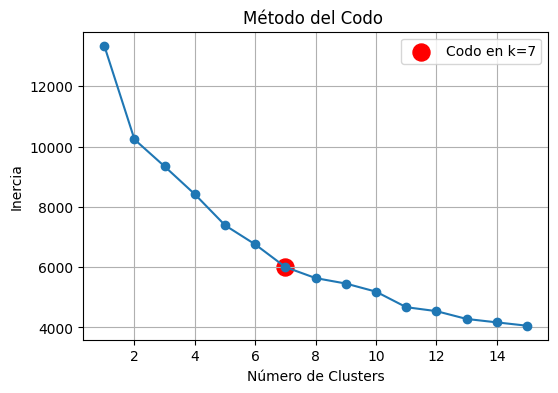

In [14]:
analisis_codo(
    df= df_item,
    feature_list= feature_list,
    scaler= RobustScaler(quantile_range=(10,90))
);

In [15]:
df_clustered_item = train_cluster(
    df= df_item,
    feature_list= feature_list,
    n_clusters= 7,
    scaler = RobustScaler(quantile_range=(10,90))
)

In [16]:
explorar_clusters(
    df= df_clustered_item,
    feature_list= feature_list
)

,cluster_items,units_sold,sell_price,income,rolling_std_3,price_change,mean_units_by_category,price_diff_from_median_item,season_dominant_winter,season_dominant_spring,season_dominant_summer,season_dominant_autumn,n_items,month_dominant
3,3,12920.669691,5.596556,57217.750657,1.998324,0.001074,7.681154,-0.007028,0.000000,1.000000,0.000000,0.000000,1102,3
2,2,12817.291667,5.221966,53637.964211,1.919996,0.001547,8.412164,-0.010693,1.000000,0.000000,0.000000,0.000000,696,2
0,0,13505.207048,4.938139,54034.093665,2.018593,0.001016,7.377276,-0.025823,0.000000,0.000000,1.000000,0.000000,454,6
5,5,12379.983721,4.543505,46699.683439,1.867906,0.001335,7.637391,-0.022452,0.000000,0.000000,0.000000,1.000000,430,10
4,4,99479.398148,3.094397,250700.082910,11.191197,0.000794,9.609761,-0.026188,0.208333,0.430556,0.291667,0.069444,216,4
6,6,7555.615385,14.012298,106013.411700,1.202531,0.009288,5.590844,-0.626372,0.392308,0.338462,0.084615,0.184615,130,2
1,1,374432.285714,2.003096,740396.466388,29.245886,0.000629,11.462063,0.002453,0.000000,0.142857,0.571429,0.285714,21,7


## Descripción de clusters

In [17]:
df_resumen_item = describir_clusters(
    df= df_clustered_item,
    feature_list= feature_list
)

In [18]:
#Redondeamos resultados
df_resumen_item['sell_price'] = df_resumen_item['sell_price'].round(2)
df_resumen_item['rolling_std_3'] = df_resumen_item['rolling_std_3'].round(2)
df_resumen_item['price_change'] = df_resumen_item['price_change'].round(4)
df_resumen_item['mean_units_by_category'] = df_resumen_item['mean_units_by_category'].round(2)
df_resumen_item['price_diff_from_median_item'] = df_resumen_item['price_diff_from_median_item'].round(4)
df_resumen_item['season_dominant_winter'] = df_resumen_item['season_dominant_winter'].round(4)
df_resumen_item['season_dominant_spring'] = df_resumen_item['season_dominant_spring'].round(4)
df_resumen_item['season_dominant_summer'] = df_resumen_item['season_dominant_summer'].round(4)
df_resumen_item['season_dominant_autumn'] = df_resumen_item['season_dominant_autumn'].round(4)
df_resumen_item['porcentaje_items'] = df_resumen_item['porcentaje_items'].round(2)
df_resumen_item['income_total'] = df_resumen_item['income_total'].round(-5).astype(int)

In [19]:
df_resumen_item

,cluster_items,sell_price,rolling_std_3,price_change,mean_units_by_category,price_diff_from_median_item,season_dominant_winter,season_dominant_spring,season_dominant_summer,season_dominant_autumn,n_items,porcentaje_items,units_sold_total,porcentaje_units_sold_total,income_total,porcentaje_income_total,month_dominant
3,3,5.60,2.00,0.0011,7.68,-0.0070,0.0000,1.0000,0.0000,0.0000,1102,36.14,14238578,21.92,63100000,27.60,3
2,2,5.22,1.92,0.0015,8.41,-0.0107,1.0000,0.0000,0.0000,0.0000,696,22.83,8920835,13.74,37300000,16.34,2
0,0,4.94,2.02,0.0010,7.38,-0.0258,0.0000,0.0000,1.0000,0.0000,454,14.89,6131364,9.44,24500000,10.74,6
5,5,4.54,1.87,0.0013,7.64,-0.0225,0.0000,0.0000,0.0000,1.0000,430,14.10,5323393,8.20,20100000,8.79,10
4,4,3.09,11.19,0.0008,9.61,-0.0262,0.2083,0.4306,0.2917,0.0694,216,7.08,21487550,33.08,54200000,23.70,4
6,6,14.01,1.20,0.0093,5.59,-0.6264,0.3923,0.3385,0.0846,0.1846,130,4.26,982230,1.51,13800000,6.03,2
1,1,2.00,29.25,0.0006,11.46,0.0025,0.0000,0.1429,0.5714,0.2857,21,0.69,7863078,12.11,15500000,6.81,7


***LAS CUATRO ESTACIONES*** *Sutiles y confiables. En esencia: clásicos*

**Características comunes:**
- La mayor parte del catálogo (~85%)
- Precios en torno a la media (~5$)
- Baja dinámica de precios
- Variabilidad de demanda estable en el corto plazo (3 semanas)
- Clara dominancia estacional

**Cluster 3:** ***Primavera***
- Mayor número de artículos, el 36% (1102)
- **Todos sus mayores picos de venta se encuentran en primavera (Top en marzo)**
- Grupo con el mayor volumen de ingresos con un 27% (~63 mill $)

**Cluster 2:** ***Invierno***
- 696 artículos (23%)
- **Todos sus mayores picos de venta se encuentran en invierno (Top en febrero)**
- 16 % de los ingresos (~37 mill $)

**Cluster 0:** ***Verano***
- 454 artículos (15%)
- **Todos sus mayores picos de venta se encuentran en verano (Top en junio)**
- 24.5 mill $ (11% de los ingresos)

**Cluster 5:** ***Otoño***
- 430 artículos (14%)
- **Todos sus mayores picos de venta se encuentran en otoño (Top en octubre)**
- 20 mill $ (9% de los ingresos)

***LA ORQUESTA*** *¿Qué es de una gran sinfonía sin una gran orquesta?*

**Cluster 4:** ***Metales*** *Firmes y potentes. Aportan intensidad*
- 216 artículos (7%)
- Supone el mayor pedazo de las ventas, con un 33%
- Supone cerca de un 24% de los ingresos del periodo estudiado
- Precios más bajos que "Las Cuatro Estaciones", con una media de 3$
- Productos con una demanda irregular en el corto plazo (3 semanas).
- Categorías relativamente numerosas
- Dominancia de la primavera, con una fuerte presencia en verano e invierno (Top en abril)
- Precios bajos, pero un alto rendimiento

**Cluster 6:** ***Violines*** *El vistuosismo de la gama alta*
- 130 artículos (4%)
- **Menor porcentaje de ventas (1.5%)**
- **Con ese bajo nivel de ventas, supone un respetable 6% de los ingresos (~13 mill $)**
- **Precios altos, con una media de 14$ (en torno a 3 veces más que "Las Cuatro Estaciones")**
- Los productos con mayor estabilidad en su demanda. Su demanda responde más al capricho del consumidor que a patrones estacionales
- Precios estables
- **Categorías con pocos productos. Más exclusivas**
- Tendencia a picos de ventas en primavera e invierno. Clara caída de la tendencia en verano (Top en febrero)

**Cluster 1:** ***Percusión*** *Los menos numerosos. Suponen los cimientos del sonido de la orquesta*
- 21 artículos (0.7%)
- Supone un 12% de las ventas y casi un 7% de los ingresos (15.5 mill $)
- **Precios más bajos y estables, 2$ de media**
- Comportamiento errático en ventas
- Una enorme variabilidad en su demanda a corto plazo (3 semanas). Conviene tratar de modelizar sus curvas de demanda de cara a mejorar la previsión de stock. *Por asociarlo con la analogía, la partitura de la percusión están llenas de compases de silencio para los diferentes instrumentos*
- Precios razonablemente estables y con cambios sutiles
- **Pertenecen a categorías con muchos productos.**
- Ligeros picos de venta en primavera que derivan en una gran cantidad de picos de venta en verano, arrastrando la tendencia ligeramente hasta el otoño (Top en julio)



In [20]:
# Cambiamos los nombres de las columnas de cluster, dejando solo las columnas necesarias para el merge
df_clustered_item = df_clustered_item.rename(columns={'cluster_items': 'cluster_item'})

# Cambiamos los nombres de los clusters
nombres_clusters_item = {
    0: "Verano",
    1: "Percusión",
    2: "Invierno",
    3: "Primavera",
    4: "Metales",
    5: "Otoño",
    6: "Violines"
}
df_clustered_item['cluster_item'] = df_clustered_item['cluster_item'].map(nombres_clusters_item)

df_clustered_item['month_dominant_rad'] = np.arctan2(df_clustered_item['month_dominant_sin'], df_clustered_item['month_dominant_cos'])
df_clustered_item['month_dominant'] = ((12 * df_clustered_item['month_dominant_rad'] / (2 * np.pi)) % 12).round().astype(int)
df_clustered_item['month_dominant'] = df_clustered_item['month_dominant'].replace(0, 12)    # Corregimos que muestre diciembre como 0
df_clustered_item.drop(['month_dominant_sin','month_dominant_cos', 'month_dominant_rad'], axis=1, inplace=True)   # Se eliminan variables no legibles

# # Guardamos una versión de df para el dashboard
# df_powerbi_item = df_clustered_item[['item','cluster_item', 'season_dominant_autumn', 'season_dominant_winter', 'season_dominant_spring', 'season_dominant_summer']]
# df_powerbi_item.to_csv('data/dashboard/df_clustering_item.csv', index=False, sep=';', decimal=',')

# Tiendas

## Data Preparation

In [21]:
df_2 = df_inicial.copy()

## Clustering por tiendas

In [22]:
df_store = df_2.groupby('store').agg({
    'units_sold': 'sum',
    'sell_price': 'mean',
    'rolling_std_3': 'mean',
    'price_change': 'mean',
    'income': 'sum'
}
).reset_index()

In [23]:
feature_list = ['units_sold', 'rolling_std_3', 'price_change', 'income']

C:\Users\jorda\AppData\Local\Temp\ipykernel_26492\2255262984.py:14: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distancias = np.abs(np.cross(linea_recta, vectores)) / np.linalg.norm(linea_recta)


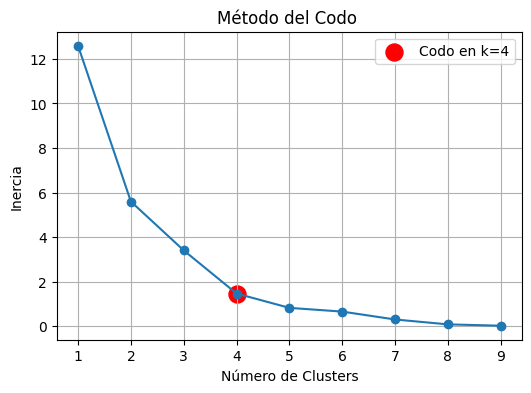

In [24]:
analisis_codo(
    df= df_store,
    feature_list= feature_list,
    scaler= RobustScaler(quantile_range=(10,90)),
    n_clusters_max= 9
);

In [25]:
df_clustered_store = train_cluster(
    df= df_store,
    feature_list= feature_list,
    n_clusters= 4,
    scaler = RobustScaler(quantile_range=(10,90)),
)

In [26]:
explorar_clusters(
    df= df_clustered_store,
    feature_list= feature_list
)

,cluster_items,units_sold,rolling_std_3,price_change,income,n_items
0,0,5326812.6,2.368051,0.001600,1.875744e+07,5
2,2,6253670.0,2.848023,0.001347,2.159267e+07,2
3,3,7368605.0,3.020807,0.001569,2.620643e+07,2
1,1,11068415.0,4.122659,0.001542,3.909424e+07,1


## Descripción de clusters

In [27]:
df_resumen_store = describir_clusters(
    df= df_clustered_store,
    feature_list= feature_list
)

In [28]:
#Redondeamos resultados
df_resumen_store['rolling_std_3'] = df_resumen_store['rolling_std_3'].round(2)
df_resumen_store['price_change'] = df_resumen_store['price_change'].round(4)
df_resumen_store['income_total'] = df_resumen_store['income_total'].round(-5).astype(int)

In [29]:
df_clustered_store

,store,units_sold,sell_price,rolling_std_3,price_change,income,cluster_items
0,Back_Bay,6023114,5.399405,2.565408,0.001414,2.172110e+07,2
1,Brooklyn,4062197,5.425921,1.895131,0.001592,1.490168e+07,0
2,Greenwich_Village,7606695,5.439670,3.098078,0.001584,2.743061e+07,3
3,Harlem,5613757,5.421518,2.439813,0.001581,2.124715e+07,0
4,Midtown_Village,5095360,5.434494,2.214864,0.001608,1.805298e+07,0
5,Queen_Village,6329140,5.443567,2.810874,0.001655,2.045157e+07,0
6,Roxbury,7130515,5.387324,2.943536,0.001553,2.498225e+07,3
7,South_End,5533609,5.392548,2.479572,0.001563,1.913381e+07,0
8,Tribeca,11068415,5.408318,4.122659,0.001542,3.909424e+07,1
9,Yorktown,6484226,5.460313,3.130638,0.001280,2.146424e+07,2


In [30]:
df_resumen_store

,cluster_items,rolling_std_3,price_change,n_items,porcentaje_items,units_sold_total,porcentaje_units_sold_total,income_total,porcentaje_income_total
0,0,2.37,0.0016,5,50.0,26634063,41.01,93800000,41.05
2,2,2.85,0.0013,2,20.0,12507340,19.26,43200000,18.90
3,3,3.02,0.0016,2,20.0,14737210,22.69,52400000,22.94
1,1,4.12,0.0015,1,10.0,11068415,17.04,39100000,17.11


***LOS ESCENARIOS***

**Cluster 1:** ***Gran Estadio*** *El espacio de los grandes eventos*
- Una única tienda (NYC_3)
- Concentra el 17% de las ventas e ingresos (39 mill $) por sí sola
- Alta variabilidad en las ventas
- Tienda con el comportamiento más impredecible

**Cluster 3:** ***Salas de concierto*** *Espacios respetados. Con buen rendimiento*
- Dos tiendas (BOS_2 y NYC_1)
- Entre las dos generan el 23% de las ventas e ingresos (52.5 mill $)
- Dinámica de precios estable

**Cluster 2:** ***Café-Teatro*** *Espacios más pequeños, pero con público fiel*
- Dos tiendas (BOS_3 y PHI_2)
- Entre las dos marcan el 20% de las ventas e ingresos
- Variabilidad media en las ventas
- Dinámica de precios estable

**Cluster 0:** ***Verbenas de pueblo*** *Muchos espacios y poco volumen. La base del ecosistema*
- Cinco tiendas (BOS_1, NYC_2 y 4, PHI_1 y 3)
- 41% de las ventas e ingresos (~94M$)
- Baja variabilidad en las ventas en el corto plazo
- De las mayores dinámicas de precios, aun así, baja en términos absolutos

In [31]:
# Cambiamos los nombres de las columnas de cluster, dejando solo las columnas necesarias para el merge
df_clustered_store = df_clustered_store.rename(columns={'cluster_items': 'cluster_store'})

# Cambiamos los nombres de los clusters
nombres_clusters_store = {
    3: "Salas de concierto",
    0: "Verbenas de pueblo",
    2: "Café-Teatro",
    1: "Gran Estadio"
}
df_clustered_store['cluster_store'] = df_clustered_store['cluster_store'].map(nombres_clusters_store)

# # Guardamos una versión de df para el dashboard
# df_powerbi_store = df_clustered_store[['store','cluster_store']]
# df_powerbi_store.to_csv('data/dashboard/df_clustering_store.csv', index=False, sep=';', decimal=',')

# Uniones

In [32]:
df = df_inicial.copy()

In [33]:
df_clustered_store

,store,units_sold,sell_price,rolling_std_3,price_change,income,cluster_store
0,Back_Bay,6023114,5.399405,2.565408,0.001414,2.172110e+07,Café-Teatro
1,Brooklyn,4062197,5.425921,1.895131,0.001592,1.490168e+07,Verbenas de pueblo
2,Greenwich_Village,7606695,5.439670,3.098078,0.001584,2.743061e+07,Salas de concierto
3,Harlem,5613757,5.421518,2.439813,0.001581,2.124715e+07,Verbenas de pueblo
4,Midtown_Village,5095360,5.434494,2.214864,0.001608,1.805298e+07,Verbenas de pueblo
5,Queen_Village,6329140,5.443567,2.810874,0.001655,2.045157e+07,Verbenas de pueblo
6,Roxbury,7130515,5.387324,2.943536,0.001553,2.498225e+07,Salas de concierto
7,South_End,5533609,5.392548,2.479572,0.001563,1.913381e+07,Verbenas de pueblo
8,Tribeca,11068415,5.408318,4.122659,0.001542,3.909424e+07,Gran Estadio
9,Yorktown,6484226,5.460313,3.130638,0.001280,2.146424e+07,Café-Teatro


In [34]:
# Dejamos solo las columnas necesarias para el merge
df_clustered_item = df_clustered_item[['item', 'cluster_item']]
df_clustered_store = df_clustered_store[['store', 'cluster_store']]

# Realizamos el merge con una comprobación de seguridad
print(f'Shape de df antes del merge: {df.shape}')
print(f'Shape de df_clustered_item antes del merge: {df_clustered_item.shape}')
print(f'Shape de df_clustered_store antes del merge: {df_clustered_store.shape}\n')
print(f'El shape final debería ser: ({df.shape[0]},{df.shape[1] + df_clustered_item.shape[1]-1 + df_clustered_store.shape[1]-1})\n')


df_clustered = df.merge(
    df_clustered_item, on='item', how='left'
).merge(
    df_clustered_store, on='store', how='left'
)

print(f'Shape después del merge: {df_clustered.shape}')

Shape de df antes del merge: (8232297, 80)
Shape de df_clustered_item antes del merge: (3049, 2)
Shape de df_clustered_store antes del merge: (10, 2)

El shape final debería ser: (8232297,82)

Shape después del merge: (8232297, 82)


In [35]:
df_clustered.columns

Index(['id', 'item', 'category', 'department', 'store', 'region', 'yearweek',
       'units_sold', 'sell_price', 'year', 'quarter',
       'producto_decreciente_ny', 'producto_creciente_ny',
       'producto_decreciente_boston', 'producto_creciente_boston',
       'producto_decreciente_phi', 'producto_creciente_phi', 'unique_id',
       'event_Buddhist', 'event_ChineeseNewYear', 'event_Christmas',
       'event_Columbus', 'event_Hindu', 'event_Independence',
       'event_JewNewYear', 'event_Juneteenth', 'event_Labour',
       'event_MartinLutherKing', 'event_Memorial', 'event_NewYear',
       'event_President', 'event_RamadanEnds', 'event_RamadanStarts',
       'event_StPatrick', 'event_Superbowl', 'event_Thanksgiving',
       'event_Veterans', 'event_YomKipur', 'event_group_buddhist',
       'event_group_chinese', 'event_group_hindu', 'event_group_islam',
       'event_group_jew', 'event_group_national', 'has_event', 'week', 'date',
       'month', 'season', 'max_wind', 'min_wind', '

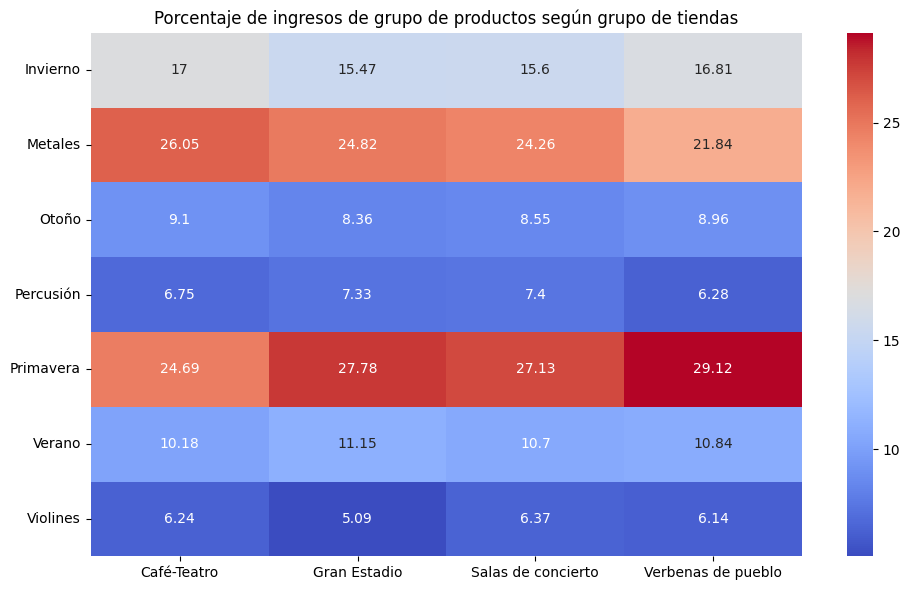

In [36]:
# Ingresos totales por combinación de producto y tienda.
tabla_cruzada_income = pd.pivot_table(
    df_clustered,
    values='income',
    index='cluster_item',
    columns='cluster_store',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Total'
)

# Del total de ingresos de cada cluster tienda: qué porcentaje proviene de cada tipo de producto.
productos_por_tienda_pct  = (
    tabla_cruzada_income.div(tabla_cruzada_income.loc['Total'], axis=1) * 100
).round(2)

plt.figure(figsize=(10, 6))
sns.heatmap(productos_por_tienda_pct.drop(index='Total', columns='Total'), annot=True, fmt='g', cmap='coolwarm')
plt.title("Porcentaje de ingresos de grupo de productos según grupo de tiendas")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


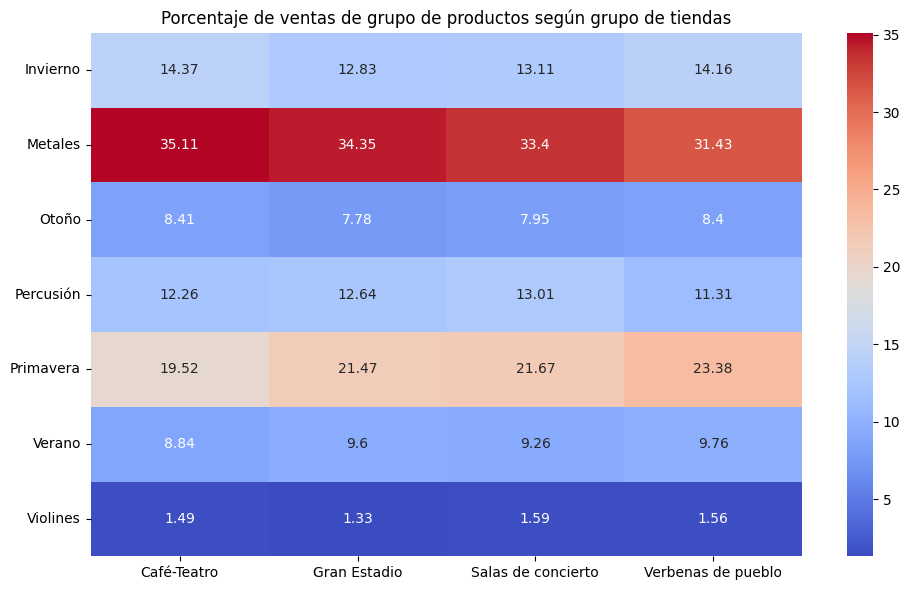

In [37]:
# Ingresos totales por combinación de producto y tienda.
tabla_cruzada_sales = pd.pivot_table(
    df_clustered,
    values='units_sold',
    index='cluster_item',
    columns='cluster_store',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Total'
)

# Del total de ventas de cada cluster tienda: qué porcentaje proviene de cada tipo de producto.
productos_por_tienda_pct  = (
    tabla_cruzada_sales.div(tabla_cruzada_sales.loc['Total'], axis=1) * 100
).round(2)

plt.figure(figsize=(10, 6))
sns.heatmap(productos_por_tienda_pct.drop(index='Total', columns='Total'), annot=True, fmt='g', cmap='coolwarm')
plt.title("Porcentaje de ventas de grupo de productos según grupo de tiendas")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [ ]:
df_clustered.to_pickle('data/pickles/df_clustered.pkl')